In [1]:
from HPNet_Pipeline import HPNet_Pipeline
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gc
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from typing import Union, List, Optional, Tuple
import sounddevice as sd


LEBEDEV = 'lebedev'
POINTS_162 = '162_points'

if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    print("Device Name:", torch.cuda.get_device_name(DEVICE))
else:
    DEVICE = torch.device("cpu")
    print("Device Name: CPU")
torch.cuda.empty_cache()  # Free up unused memory on GPU
gc.collect()  # Clean up unused memory on CPU


Device Name: NVIDIA GeForce RTX 4080 SUPER


36

In [18]:
def plot_spectograms(anm_f,sr):
    n_fft = int(2*(anm_f.shape[-1]-1))      # Extract # FFT points from size of anm_f
    hop_length = n_fft//2   # Hop length (stride)
    win_length = n_fft   # Window length
    for channel_id in range(anm_f.shape[1]):
        plt.figure()
        magnitude = torch.abs(anm_f[:,channel_id]).t()
        freq_bins, time_frames = magnitude.shape
        sr = sr
        time_axis = (torch.arange(time_frames) * hop_length) / sr  # Time in seconds
        freq_axis = torch.arange(freq_bins) * (sr / n_fft) 
        plt.imshow(20*torch.log10(magnitude + 1e-6),
            aspect='auto', 
            origin='lower', 
            extent=[time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]],
        )
        plt.colorbar(label='Magnitude (dB)')
        plt.xlabel('Time [s]')
        plt.ylabel('Frequency [Hz]')
        plt.title(f'Spectrogram of Channel {channel_id}')
def play_sound_field_from_stft(anm_f,sr,amplify):
    n_fft = int(2*(anm_f.shape[-1]-1))      # Extract # FFT points from size of anm_f
    hop_length = n_fft//2   # Hop length (stride)
    win_length = n_fft   # Window length
    mono_signal = torch.istft(anm_f[:,0].t(),#torch.sum(anm_f, dim=1).t(),
                n_fft=n_fft,
                hop_length= hop_length,
                win_length=win_length,
                window = torch.hann_window(win_length)
                )
    mono_signal_np = mono_signal.numpy() * amplify
    sd.play(mono_signal_np, samplerate=sr)
def play_sparse_stft_sound_field(
    dict_stft: torch.tensor,
    P_ph : List[Tuple[float, float]],
    P_th : List[Tuple[float, float]],
    sr : int,
    theta: float,
    phi: float,
    radius: float = 5,
    amplify : float = 1,
    window: Union[int, None] = None,
    bin: Union[int, None] = None,
):
    

    if dict_stft.dtype == torch.complex64:
            complex_sparse_stft_dict = dict_stft
    else:
        T_shape = dict_stft.shape[-1]//2
        complex_sparse_stft_dict = torch.complex(dict_stft[...,:T_shape],dict_stft[...,T_shape:])
    n_fft = int(2*(num_bins - 1))      # Extract # FFT points from size of anm_f
    hop_length = n_fft//2   # Hop length (stride)
    win_length = n_fft   # Window length
    time_signal = torch.istft(complex_sparse_stft_dict.permute(1, 2, 0).cpu(),#torch.sum(anm_f, dim=1).t(),
        n_fft=n_fft,
        hop_length= hop_length,
        win_length=win_length,
        window = torch.hann_window(win_length)
        )


    grid_in_degress = torch.stack((P_ph, P_th)).T * 180 / torch.pi
    target_in_degress = torch.tensor([phi, theta]).reshape(1, -1)
    relevant_grid_points = (
        (torch.norm(grid_in_degress - target_in_degress, p=2, dim=1) < radius)
        .nonzero()
        .flatten()
    )

    if len(relevant_grid_points) > 0:
        print("## Playing Directions ##")
        for i in relevant_grid_points:
            print(f"{i} : Theta = {grid_in_degress[i,1]}, Phi = {grid_in_degress[i,0]}")
    else:
        print("No directions found")
        return

    energy = (time_signal**2).sum()
    normalized_time_signal = time_signal / torch.sqrt(energy)
    signal = torch.sum(normalized_time_signal[relevant_grid_points, :], axis=0)
    sd.play(amplify * signal.cpu().numpy(), sr)


In [4]:
dataset_path = r"data\ModelDataSets\WSJ_4_3_25"
grid = POINTS_162
pipeline = HPNet_Pipeline(dataset_path=dataset_path, grid_type=grid)

In [5]:
pipeline.init_params(
    batch_size=1,
    n_fft=256,
    T=10,
    init_mu=1e-3,
    init_ro=1e-3,
    num_iters=10000,
    adam_lr=1e-2,
    version=5,
    device=DEVICE,
)

Optimization Method : GD_lagrange_multi 


In [6]:
audio_id,low_order_anmt,high_order_anmt = pipeline.train_set[0]
print(audio_id,low_order_anmt.shape)


22 torch.Size([250, 4, 129])


DU_Optimizer:   0%|          | 0/10000 [00:00<?, ?it/s]

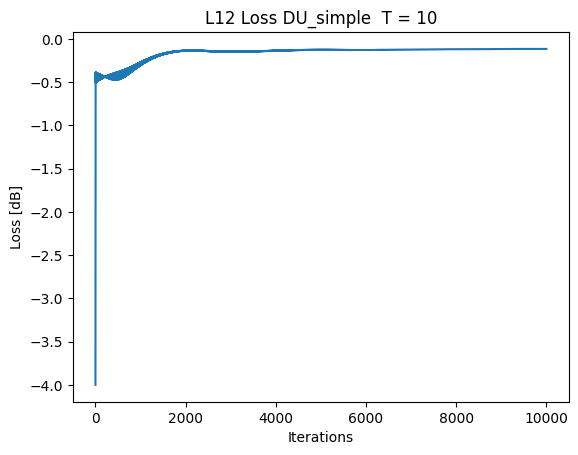

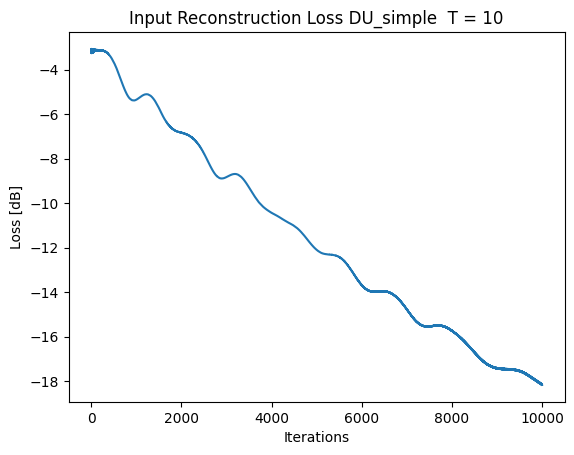

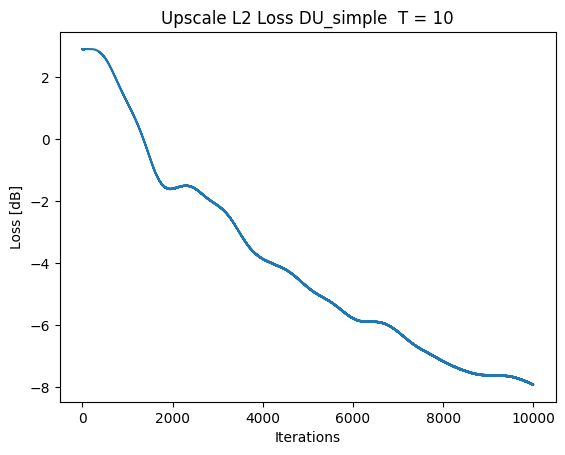

Upscaled Loss : tensor([-7.9036], device='cuda:0')


In [7]:
with torch.no_grad():
    #Runs with init mu/ro only
    pipeline.run_optimizer(
        from_iter=0,
        to_iter=10000,
        low_order_stft=low_order_anmt.unsqueeze(0),
        high_order_stft=high_order_anmt.unsqueeze(0),
        progress_per_iter=True,
        classic_model=True
    )
    print(f"Upscaled Loss : {pipeline.classic_opt.upscaled_loss(loss_in_dB=True)}")

In [8]:
s_t,lagarange = pipeline.classic_opt.get_current_state()

In [20]:
play_sparse_stft_sound_field(dict_stft=s_t,P_th=pipeline.P_th,P_ph=pipeline.P_ph,theta=11,phi=-4,radius=15,amplify=10,sr=pipeline.train_set.sr)

Value(False)


RuntimeError: The size of tensor a (64) must match the size of tensor b (65) at non-singleton dimension 2

In [10]:
s_t,lagarange = pipeline.du_opt.get_current_state()

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 | Loss : -7.910016775131226 dB
Epoch 1 | Loss : -7.911442518234253 dB
Epoch 2 | Loss : -7.912954092025757 dB
Epoch 3 | Loss : -7.914400696754456 dB
Epoch 4 | Loss : -7.9156506061553955 dB
Epoch 5 | Loss : -7.916952967643738 dB
Epoch 6 | Loss : -7.91837215423584 dB
Epoch 7 | Loss : -7.919510006904602 dB
Epoch 8 | Loss : -7.920277118682861 dB
Epoch 9 | Loss : -7.921167612075806 dB
Epoch 10 | Loss : -7.921760082244873 dB
Epoch 11 | Loss : -7.922317981719971 dB
Epoch 12 | Loss : -7.9229021072387695 dB
Epoch 13 | Loss : -7.92348325252533 dB
Epoch 14 | Loss : -7.924094796180725 dB
Epoch 15 | Loss : -7.924463152885437 dB
Epoch 16 | Loss : -7.92497992515564 dB
Epoch 17 | Loss : -7.925276756286621 dB
Epoch 18 | Loss : -7.925615906715393 dB
Epoch 19 | Loss : -7.925940752029419 dB
Epoch 20 | Loss : -7.926188707351685 dB
Epoch 21 | Loss : -7.926533818244934 dB
Epoch 22 | Loss : -7.926762700080872 dB
Epoch 23 | Loss : -7.926986813545227 dB
Epoch 24 | Loss : -7.9271358251571655 dB
Epoch 25 |

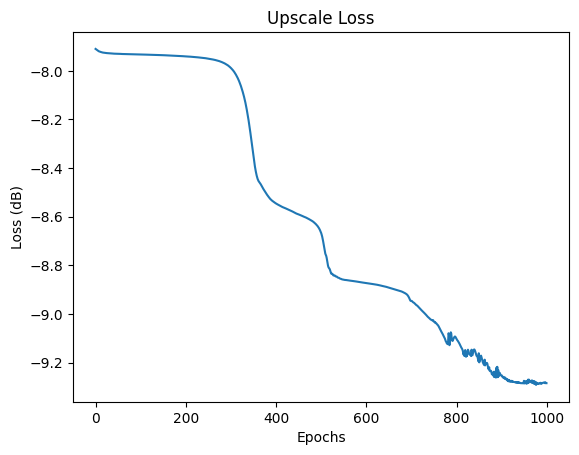

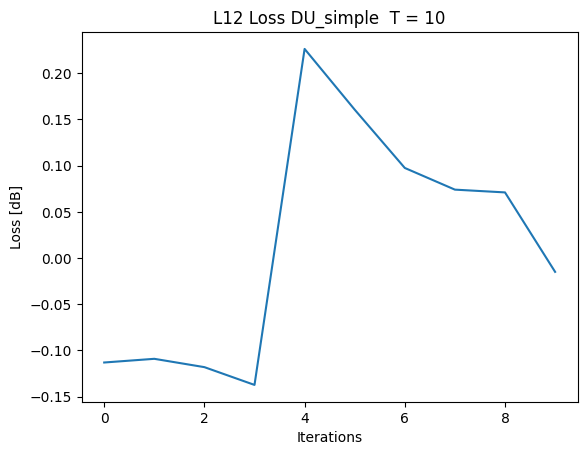

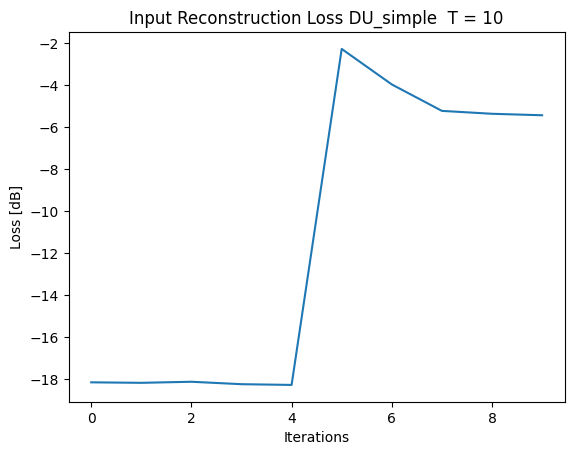

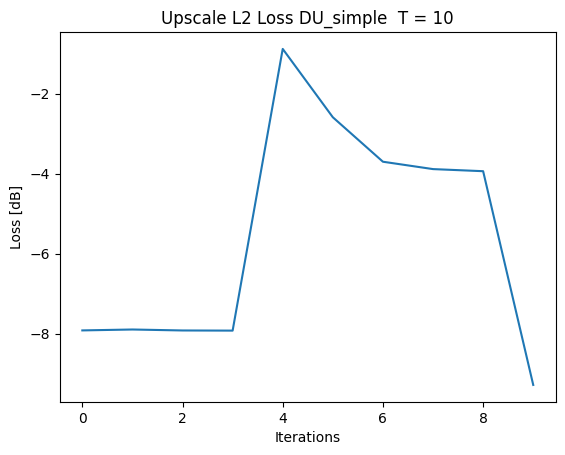

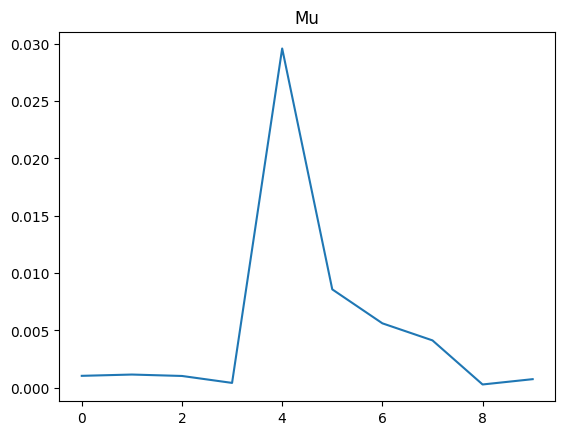

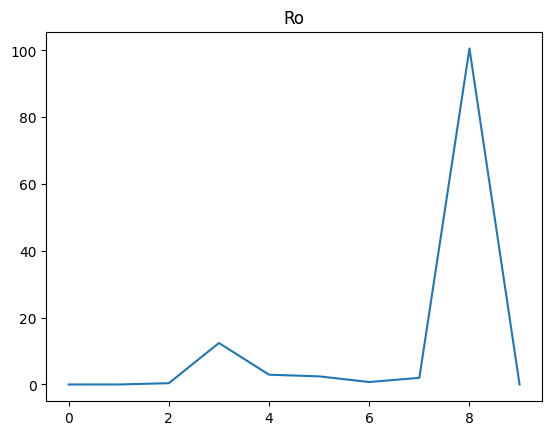

In [8]:
epochs = 1000
num_iters = 10
first_iter = 0
loss_per_epoch = list()
for epoch in tqdm(range(epochs)):
    pipeline.run_optimizer(
        from_iter=first_iter,
        to_iter=first_iter + num_iters,
        low_order_stft=low_order_anmt.unsqueeze(0),
        high_order_stft=high_order_anmt.unsqueeze(0),
        progress_per_iter=False,
        init_lagrange=lagarange.detach().clone(),
        init_st=s_t.detach().clone(),
        disable_tqdm=True,
    )
    loss  = pipeline.du_opt.upscaled_loss()
    pipeline.training_opt.zero_grad()
    loss.backward()
    pipeline.training_opt.step()
    loss_per_epoch.append(10*torch.log10(loss).item())
    print(f"Epoch {epoch} | Loss : {loss_per_epoch[-1]} dB")

plt.plot(loss_per_epoch)
plt.xlabel("Epochs")
plt.ylabel("Loss (dB)")
plt.title("Upscale Loss")


with torch.no_grad():
    pipeline.run_optimizer(
    from_iter=first_iter,
    to_iter=first_iter + num_iters,
    low_order_stft=low_order_anmt.unsqueeze(0),
    high_order_stft=high_order_anmt.unsqueeze(0),
    progress_per_iter=True,
    disable_tqdm=True,
    init_lagrange=lagarange.detach().clone(),
    init_st=s_t.detach().clone(),
)
    
plt.figure()
plt.plot(pipeline.du_opt.HP_model.mu.exp().detach().cpu()[first_iter:first_iter + num_iters].squeeze())
plt.title("Mu")
plt.figure()
plt.plot(pipeline.du_opt.HP_model.ro.exp().detach().cpu()[first_iter:first_iter + num_iters].squeeze())
plt.title("Ro")
plt.show()

DU_Optimizer:   0%|          | 0/20 [00:00<?, ?it/s]

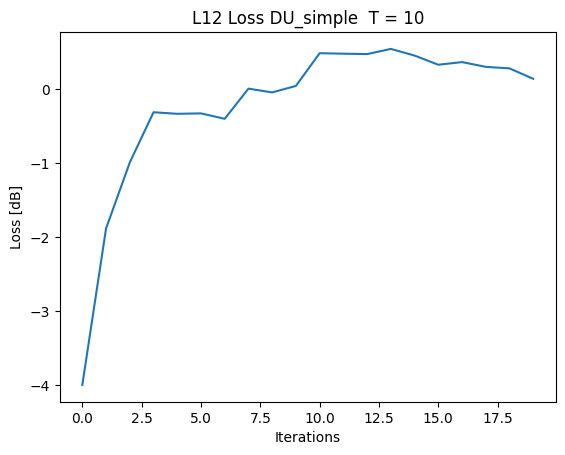

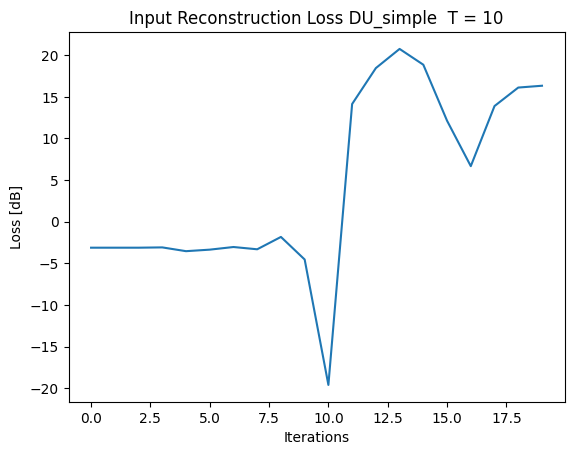

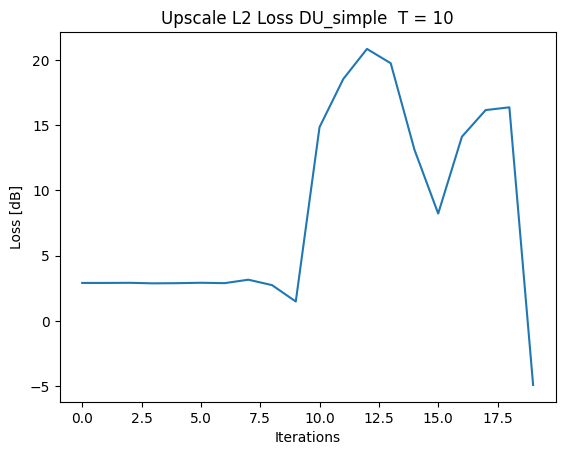

AttributeError: 'optimizer' object has no attribute 'complex_gt_stft_anmt'

In [8]:

with torch.no_grad():
#Runs with init mu/ro only
    pipeline.run_optimizer(
        from_iter=0,
        to_iter=20,
        low_order_stft=low_order_anmt.unsqueeze(0),
        high_order_stft=high_order_anmt.unsqueeze(0),
        progress_per_iter=True,
    )
    print(f"Upscaled Loss : {pipeline.classic_opt.upscaled_loss(loss_in_dB=True)}")


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 | Loss : 2.8971484303474426 dB
Epoch 1 | Loss : 2.8966692090034485 dB
Epoch 2 | Loss : 2.8965184092521667 dB
Epoch 3 | Loss : 2.8963422775268555 dB
Epoch 4 | Loss : 2.8960928320884705 dB
Epoch 5 | Loss : 2.895873785018921 dB
Epoch 6 | Loss : 2.895684838294983 dB
Epoch 7 | Loss : 2.8954991698265076 dB
Epoch 8 | Loss : 2.8952935338020325 dB
Epoch 9 | Loss : 2.895069420337677 dB
Epoch 10 | Loss : 2.894856631755829 dB
Epoch 11 | Loss : 2.894681990146637 dB
Epoch 12 | Loss : 2.8944963216781616 dB
Epoch 13 | Loss : 2.8942790627479553 dB
Epoch 14 | Loss : 2.8940892219543457 dB
Epoch 15 | Loss : 2.8939181566238403 dB
Epoch 16 | Loss : 2.8937378525733948 dB
Epoch 17 | Loss : 2.8935465216636658 dB
Epoch 18 | Loss : 2.893373966217041 dB
Epoch 19 | Loss : 2.8932255506515503 dB
Epoch 20 | Loss : 2.893054485321045 dB
Epoch 21 | Loss : 2.8928735852241516 dB
Epoch 22 | Loss : 2.8927060961723328 dB
Epoch 23 | Loss : 2.8925272822380066 dB
Epoch 24 | Loss : 2.89234459400177 dB
Epoch 25 | Loss : 2

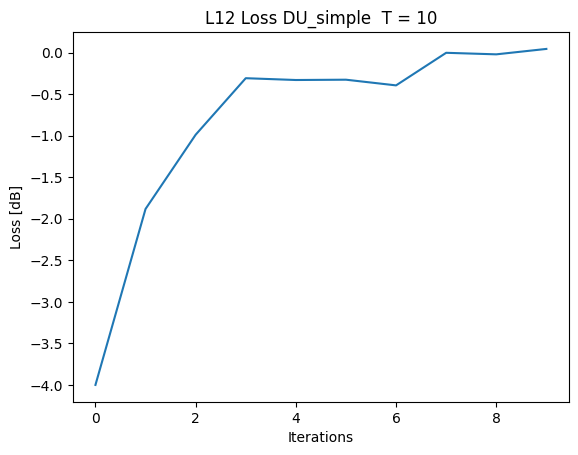

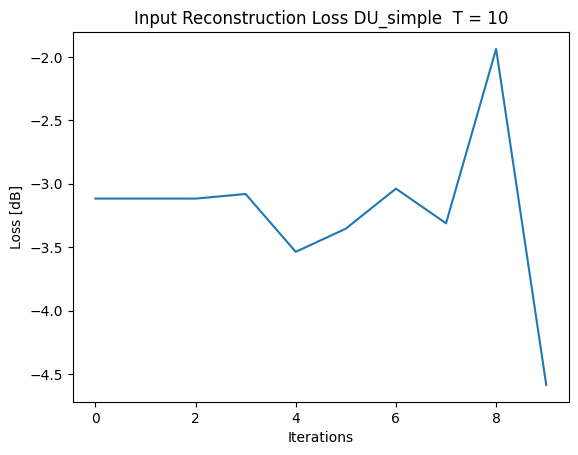

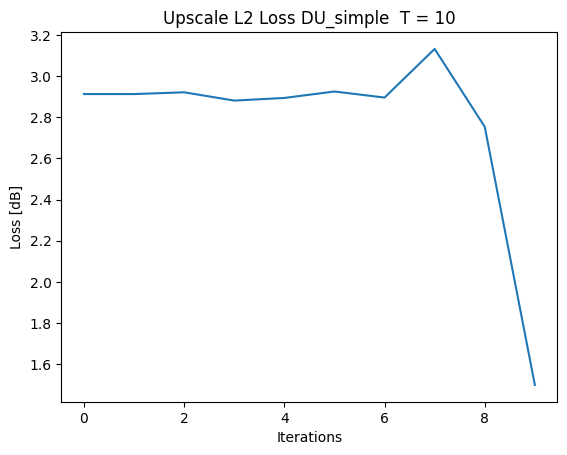

Finished Iteration Group 0 - 10 : 


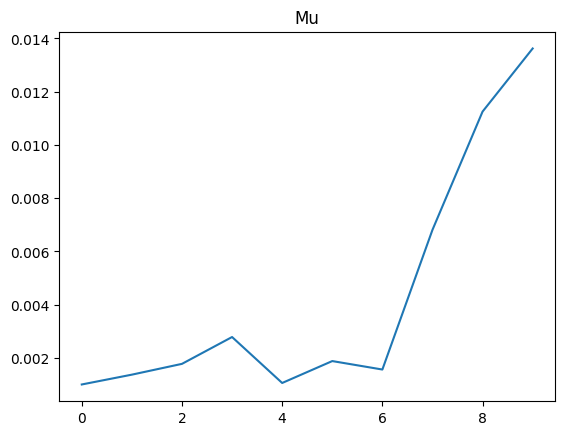

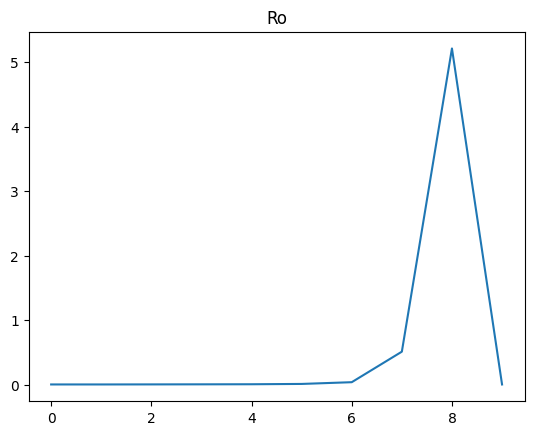

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 | Loss : 1.866024136543274 dB
Epoch 1 | Loss : 1.8420056998729706 dB
Epoch 2 | Loss : 1.8116490542888641 dB
Epoch 3 | Loss : 1.7789098620414734 dB
Epoch 4 | Loss : 1.7460739612579346 dB
Epoch 5 | Loss : 1.7144377529621124 dB
Epoch 6 | Loss : 1.6847440600395203 dB
Epoch 7 | Loss : 1.6574987769126892 dB
Epoch 8 | Loss : 1.6328753530979156 dB
Epoch 9 | Loss : 1.6108343005180359 dB
Epoch 10 | Loss : 1.5912649035453796 dB
Epoch 11 | Loss : 1.5738901495933533 dB
Epoch 12 | Loss : 1.558646410703659 dB
Epoch 13 | Loss : 1.5453064441680908 dB
Epoch 14 | Loss : 1.5336167812347412 dB
Epoch 15 | Loss : 1.5234065055847168 dB
Epoch 16 | Loss : 1.5144804120063782 dB
Epoch 17 | Loss : 1.5067197382450104 dB
Epoch 18 | Loss : 1.499912440776825 dB
Epoch 19 | Loss : 1.493966430425644 dB
Epoch 20 | Loss : 1.4887319505214691 dB
Epoch 21 | Loss : 1.4841847121715546 dB
Epoch 22 | Loss : 1.4801710844039917 dB
Epoch 23 | Loss : 1.4766581356525421 dB
Epoch 24 | Loss : 1.473541408777237 dB
Epoch 25 | Loss

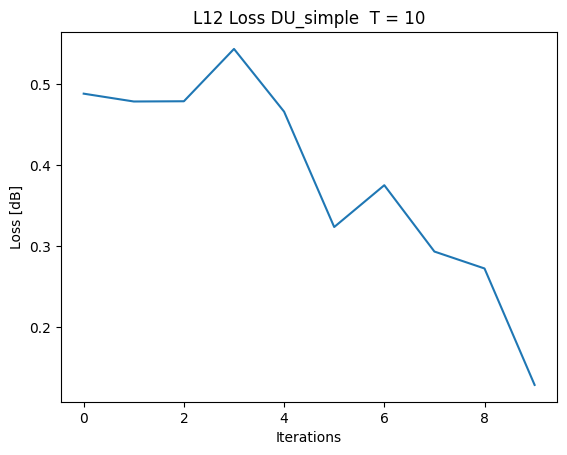

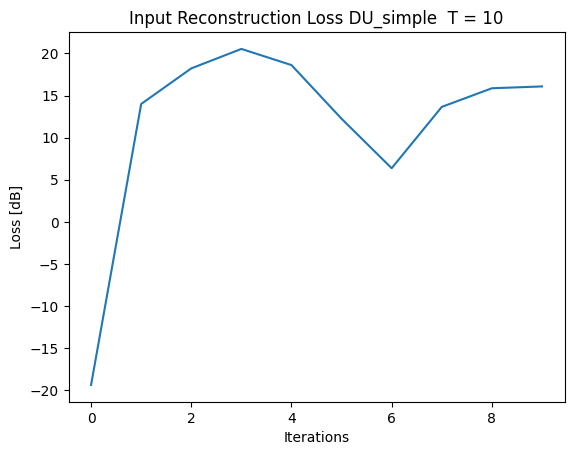

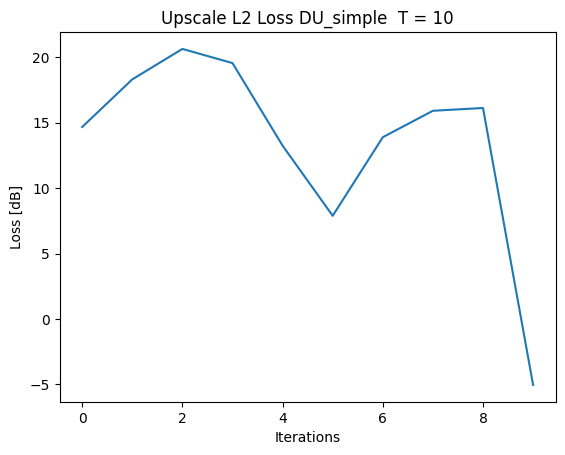

Finished Iteration Group 10 - 20 : 


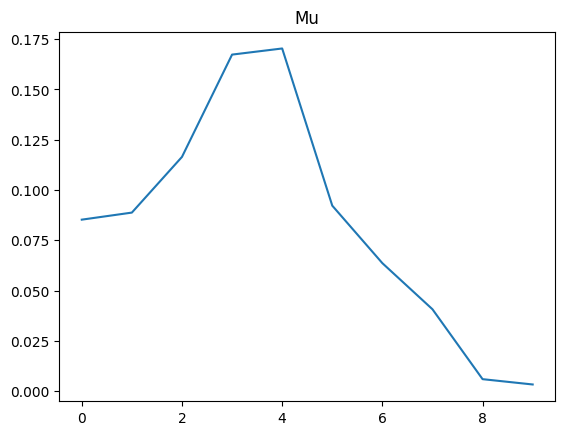

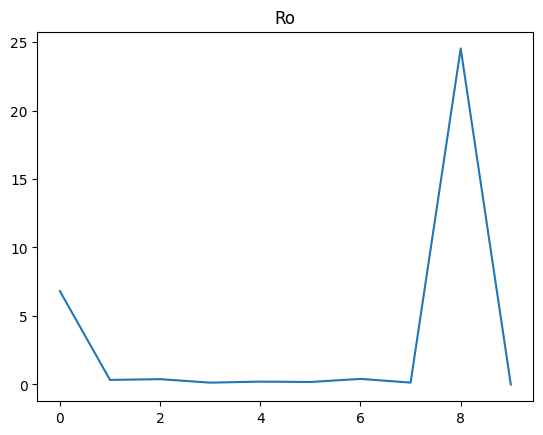

Text(0.5, 1.0, 'Upscale Loss')

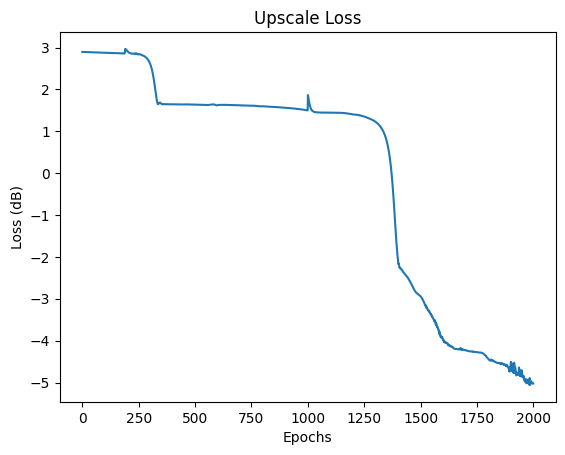

In [7]:
epochs = 1000
num_iters = 10
loss_per_epoch = list()
iter_groups = torch.arange(0, 20, num_iters)
init_st = None
init_lagarange = None
for first_iter in iter_groups:
    pipeline.training_opt = torch.optim.Adam(pipeline.du_opt.parameters(), lr=1e-2)
    for epoch in tqdm(range(epochs)):
        pipeline.run_optimizer(
            from_iter=first_iter,
            to_iter=first_iter + num_iters,
            low_order_stft=low_order_anmt.unsqueeze(0),
            high_order_stft=high_order_anmt.unsqueeze(0),
            progress_per_iter=False,
            disable_tqdm=True,
            init_lagrange=init_lagarange.detach() if init_lagarange is not None else None,
            init_st=init_st.detach() if init_st is not None else None,
        )
        loss  = pipeline.du_opt.upscaled_loss()
        pipeline.training_opt.zero_grad()
        loss.backward()
        pipeline.training_opt.step()
        loss_per_epoch.append(10*torch.log10(loss).item())
        print(f"Epoch {epoch} | Loss : {loss_per_epoch[-1]} dB")

    with torch.no_grad():
        pipeline.run_optimizer(
        from_iter=first_iter,
        to_iter=first_iter + num_iters,
        low_order_stft=low_order_anmt.unsqueeze(0),
        high_order_stft=high_order_anmt.unsqueeze(0),
        progress_per_iter=True,
        disable_tqdm=True,
        init_lagrange=init_lagarange.detach() if init_lagarange is not None else None,
        init_st=init_st.detach() if init_st is not None else None,
    )
    print(f"Finished Iteration Group {first_iter} - {first_iter + num_iters} : ")
    plt.figure()
    plt.plot(pipeline.du_opt.HP_model.mu.exp().detach().cpu()[first_iter:first_iter + num_iters].squeeze())
    plt.title("Mu")
    plt.figure()
    plt.plot(pipeline.du_opt.HP_model.ro.exp().detach().cpu()[first_iter:first_iter + num_iters].squeeze())
    plt.title("Ro")
    plt.show()
    init_st ,init_lagarange = pipeline.du_opt.get_current_state() #assumes last epoch is best - TODO save best result and move from it

plt.plot(loss_per_epoch)
plt.xlabel("Epochs")
plt.ylabel("Loss (dB)")
plt.title("Upscale Loss")